<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L06-Modelos_ARMA/notebooks/L06_1_ModelosARMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pmdarima # Ojo: Después de la primera instalación se puede comentar esta línea

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # para gráficos en enrejados irregulares
import seaborn as sns # Gráficos estadísticos
import statsmodels.graphics.tsaplots as smt # para gráficos ACF y PACF
from statsmodels.tsa.arima_process import arma_generate_sample # para simulación ARIMA
from pmdarima import auto_arima

np.random.seed(10) # para reproducibilidad de simulaciones

In [2]:
# Subir archivo pounds_nz.dat
from google.colab import files
files.upload()

Saving pounds_nz.dat to pounds_nz (4).dat


{'pounds_nz (4).dat': b'xrate\n2.9243\n2.9422\n3.1719\n3.2542\n3.3479\n3.5066\n3.0027\n2.844\n2.8378\n2.7301\n2.7008\n2.6138\n2.5874\n2.5787\n2.547\n2.4701\n2.3895\n2.375\n2.3859\n2.2766\n2.2351\n2.245\n2.3208\n2.339\n2.3687\n2.512\n2.6917\n2.8435\n3.0922\n3.2528\n3.1852\n3.034\n2.9593\n3.0498\n3.1869\n3.2286\n3.1925\n3.3522\n3.531\n\n\n'}

In [3]:
df = pd.read_csv('/content/pounds_nz.dat')
df.head()

,xrate
0,2.9243
1,2.9422
2,3.1719
3,3.2542
4,3.3479


In [4]:
df['Fecha'] = pd.period_range(start='1991-01', periods=len(df), freq='Q')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.tail()

,xrate
Fecha,
1999-07-01,3.1869
1999-10-01,3.2286
2000-01-01,3.1925
2000-04-01,3.3522
2000-07-01,3.5310


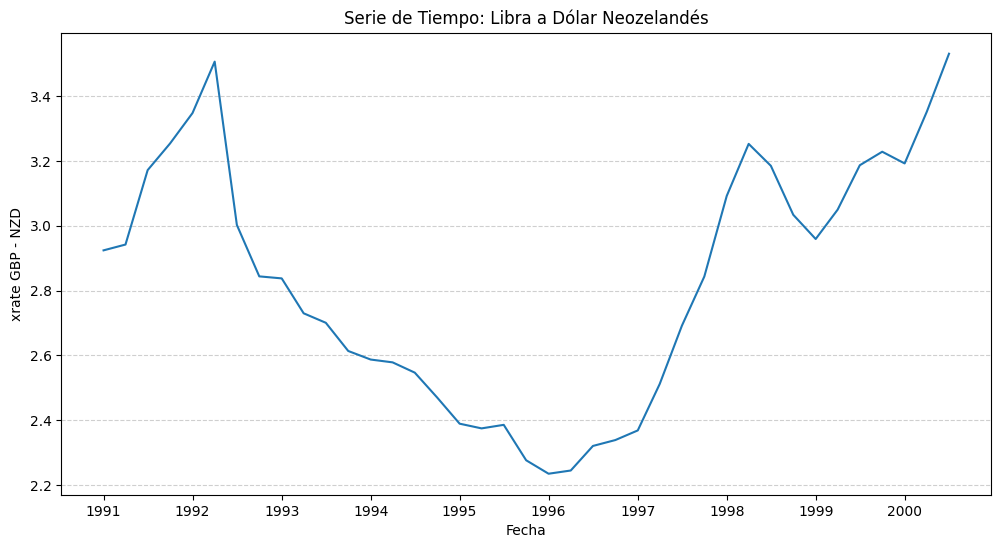

In [5]:
# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['xrate'])

# Etiquetas
plt.title('Serie de Tiempo: Libra a Dólar Neozelandés')
plt.xlabel('Fecha')
plt.ylabel('xrate GBP - NZD')

# Formato
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# **Modelo AR**

In [6]:
# Definiendo los parámetros para un modelo AR(4)
# El polinomio AR es 1 - ar1*B - ar2*B^2 - ar3*B^3 - ar4*B^4
# Entonces, los coeficientes para generar la simulación deben ser [1, -ar1, -ar2, -ar3, -ar4]
# En este ejemplo ar1 = ar2 = ar3 = ar4 = 0.2
# Los coeficientes AR en esta función se colocan con el signo contrario (por la estructura del polinomio)
ar_coef = [1, -0.2, -0.2, -0.2, -0.2]

# El coeficiente de la parte MA se coloca en 1 por el lag-0 de la serie de ruido incluida en el modelo
ma_coef = [1]

# Generando los datos simulados con un intercepto en -15
ar_sim = -15 + arma_generate_sample(
    ar=ar_coef, ma=ma_coef, nsample=1000
)

ar_sim[:10] # el objeto es un arreglo de numpy

array([-13.6684135 , -14.01840372, -16.08276374, -14.76230004,
       -14.08504023, -15.50978711, -14.82246664, -14.72737028,
       -14.82464142, -15.1514533 ])

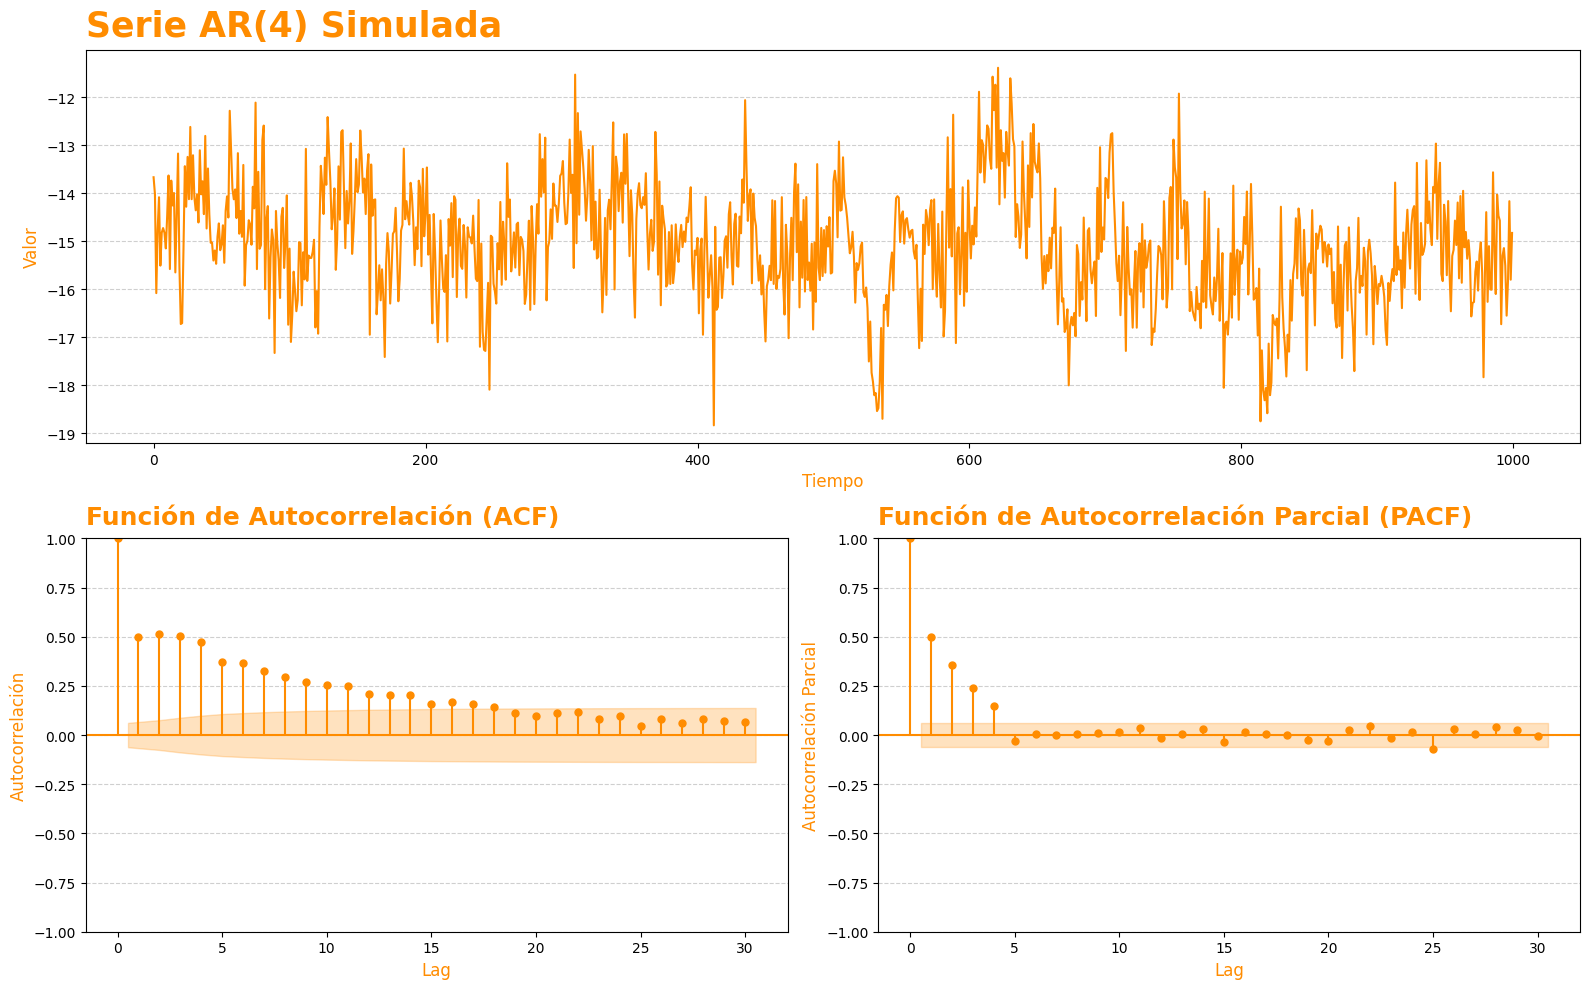

In [7]:
# Gráfico de Simulaciones
serie = ar_sim
nombre = 'AR(4) Simulada'
graphColor = 'darkorange'

# Crear la figura y el GridSpec para el layout de 2x2
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Subplot para la serie simulada (ocupa toda la fila superior)
ax0 = fig.add_subplot(gs[0, :]) # gs[0, :] indica la primera fila, todas las columnas
ax0.plot(serie, color = graphColor)
ax0.set_title('Serie ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Tiempo', fontsize=12, color = graphColor,)
ax0.set_ylabel('Valor', fontsize=12, color = graphColor,)
ax0.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la ACF (parte inferior izquierda)
ax1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] indica la segunda fila, primera columna
smt.plot_acf(serie, lags=30, ax=ax1, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y formato
ax1.set_title('Función de Autocorrelación (ACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax1.set_ylabel('Autocorrelación', fontsize=12, color = graphColor)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la PACF (parte inferior derecha)
ax2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] indica la segunda fila, segunda columna
smt.plot_pacf(serie, lags=30, ax=ax2, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y Formato
ax2.set_title('Función de Autocorrelación Parcial (PACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax2.set_ylabel('Autocorrelación Parcial', fontsize=12, color = graphColor)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout() # Ajustar el layout para evitar empalme
plt.show()

## Ajuste de un modelo AR a datos reales (NZD-GBP)

In [8]:
# Ajuste de un modelo AR(1)
ar_model = auto_arima(df['xrate'],
                       start_p=1, max_p=1,
                       information_criterion = 'bic',
                       # Parámetros NO utilizados en este momento:
                       seasonal=False,
                       start_q=0, max_q=0,
                       d=0,
                       D=0
                      )

print(ar_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  21.702
Date:                Sun, 21 Jun 2026   AIC                            -37.404
Time:                        07:56:30   BIC                            -32.413
Sample:                    01-01-1991   HQIC                           -35.614
                         - 07-01-2000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1686      0.202      0.836      0.403      -0.227       0.564
ar.L1          0.9440      0.065     14.446      0.000       0.816       1.072
sigma2         0.0182      0.004      4.902      0.0

- Sigma2: Varianza de los resiguales. Entre más baja mejor ajuste del modelo a los datos, ya que implica que las predicciones están más cerca de los valores.

- Ljung-Box: Prueba de autocorrelación. $H_0$ : No hay autocorrelación $H_1$ : Hay autocorrelación

- Heterocedasticidad: $H_0$ : No hay heterocedasticidad $H_1$ Sí hay heterocedasticidad.

In [9]:
# Obtener valores ajustados y predicciones
modelo = ar_model
pasos = 20
nombreSerie = 'Tipo de Cambio GBP - NZD'
nombreModelo = 'AR(1)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Generar predicciones con intervalos de confianza
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfFor = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfFor.head()

Fecha
1991-01-01    3.010632
1991-04-01    2.929136
1991-07-01    2.946033
1991-10-01    3.162866
1992-01-01    3.240556
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2000-10-01,3.501851,3.237622,3.766079
2001-01-01,3.474335,3.110974,3.837695
2001-04-01,3.448360,3.015382,3.881338
2001-07-01,3.423840,2.937145,3.910535
2001-10-01,3.400694,2.870699,3.930689


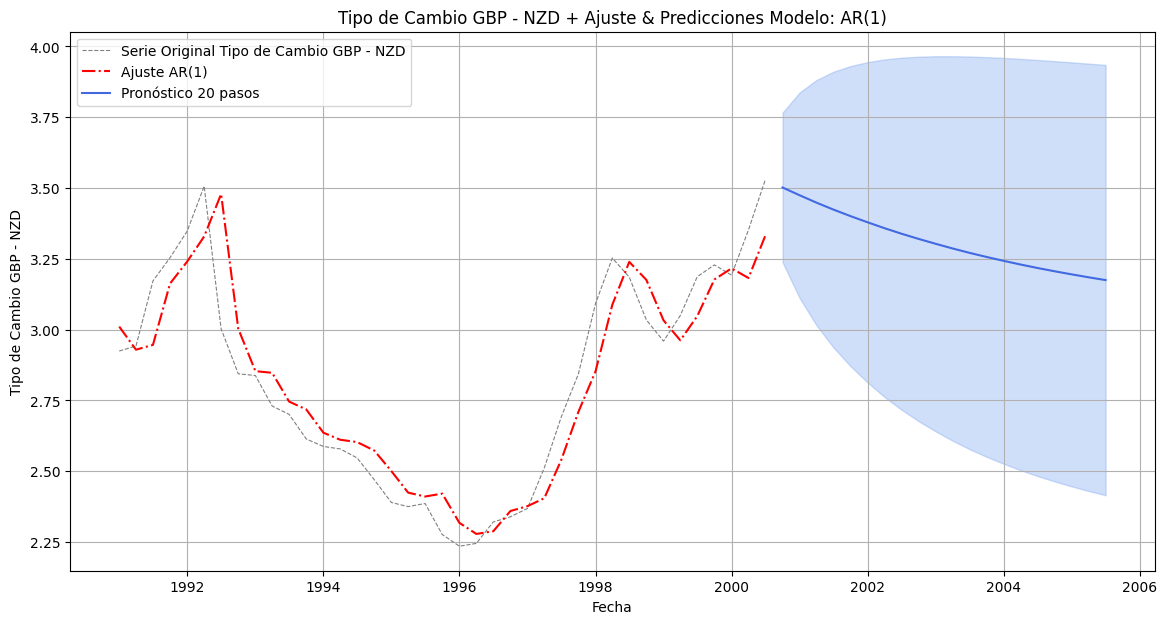

In [10]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['xrate'], label='Serie Original ' + nombreSerie, color = 'gray', linestyle='--', lw = 0.8)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='-.')
# Gráfico Pronóstico puntual
plt.plot(dfFor.index, dfFor['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfFor.index, dfFor['cotaInf'], dfFor['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(True)
plt.show()

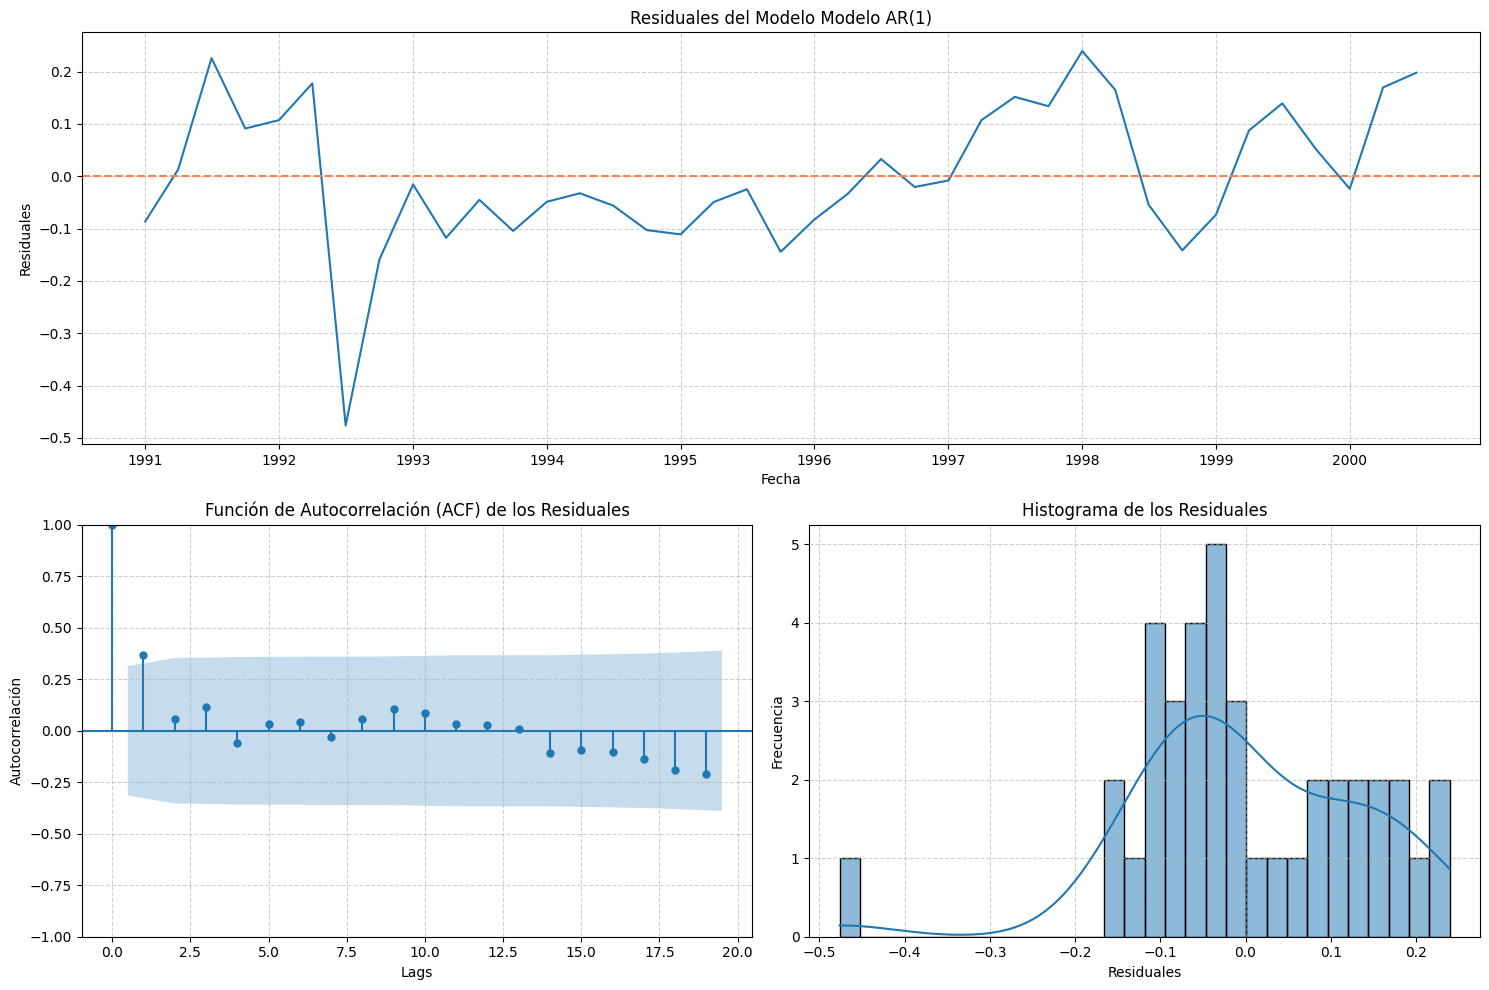

In [11]:
# Gráficos de Residuales
modelo = ar_model
nombre = 'Modelo AR(1)'

# Asegurarse de que los residuales sean una Serie con el mismo índice que df
# Ojo porque para modelos ARIMA tenemos que llamar a la función resid() para obtener los residuales
residuales = pd.Series(modelo.resid(), index=df.index)

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=min(len(residuales) // 2, 40), ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Modelo MA**

In [12]:
# Definiendo los parámetros para un modelo MA(4)
# El polinomio MA es 1 + ma1*B + ma2*B^2 + ma3*B^3 + ma4*B^4
# Entonces, los coeficientes para generar la simulación deben ser [1, ma1, ma2, ma3, ma4]
# En este ejemplo ma1 = ma2 = ma3 = ma4 = 0.2

# Para un modelo MA puro, el coeficiente AR es simplemente [1]
ar_coef = [1]

# Los coeficientes MA se colocan directamente, incluyendo el lag-0
ma_coef = [1, 0.2, 0.2, 0.2, 0.2]

# Generando los datos simulados con un intercepto en -15
ma_sim = -15 + arma_generate_sample(
    ar=ar_coef, ma=ma_coef, nsample=1000
)

ma_sim[:10] # el objeto es un arreglo de numpy

array([-13.48674777, -14.83968314, -14.86523623, -13.57819272,
       -13.33480974, -13.90108414, -15.63445683, -14.10292072,
       -14.51784223, -14.69895542])

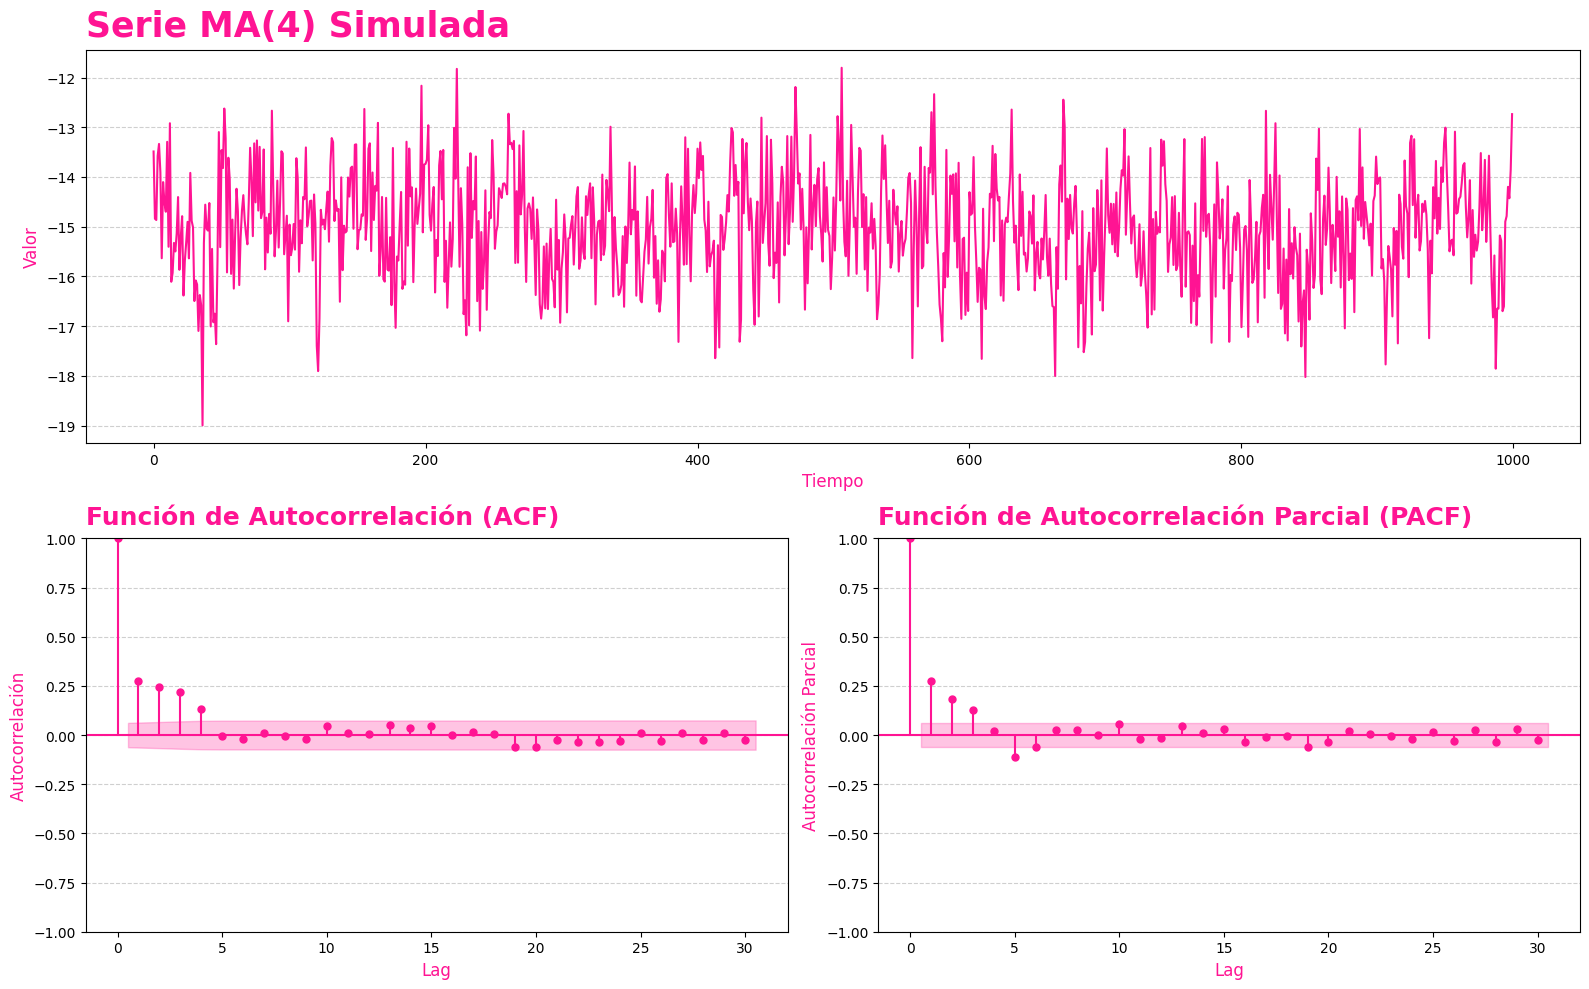

In [13]:
# Gráfico de Simulaciones
serie = ma_sim
nombre = 'MA(4) Simulada'
graphColor = 'deeppink'

# Crear la figura y el GridSpec para el layout de 2x2
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Subplot para la serie simulada (ocupa toda la fila superior)
ax0 = fig.add_subplot(gs[0, :]) # gs[0, :] indica la primera fila, todas las columnas
ax0.plot(serie, color = graphColor)
ax0.set_title('Serie ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Tiempo', fontsize=12, color = graphColor,)
ax0.set_ylabel('Valor', fontsize=12, color = graphColor,)
ax0.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la ACF (parte inferior izquierda)
ax1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] indica la segunda fila, primera columna
smt.plot_acf(serie, lags=30, ax=ax1, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y formato
ax1.set_title('Función de Autocorrelación (ACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax1.set_ylabel('Autocorrelación', fontsize=12, color = graphColor)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la PACF (parte inferior derecha)
ax2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] indica la segunda fila, segunda columna
smt.plot_pacf(serie, lags=30, ax=ax2, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y Formato
ax2.set_title('Función de Autocorrelación Parcial (PACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax2.set_ylabel('Autocorrelación Parcial', fontsize=12, color = graphColor)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout() # Ajustar el layout para evitar empalme
plt.show()

## Ajuste de un modelo MA a datos reales (NZD-GBP)

In [14]:
# Ajuste de un modelo MA automático con q de 1 a 5
ma_model = auto_arima(df['xrate'],
                       start_p=0, max_p=0,
                       start_q=1, max_q=5,
                       information_criterion = 'aic',
                       stepwise = False, # Prueba de TODOS los modelos posibles
                       with_intercept = True, # Que incluya un intercepto
                       # Parámetros NO utilizados en este momento:
                       seasonal=False,
                       d=0, # Allow auto_arima to determine differencing order
                       D=0
                      )

print(ma_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:               SARIMAX(0, 0, 2)   Log Likelihood                  13.062
Date:                Sun, 21 Jun 2026   AIC                            -18.125
Time:                        07:56:40   BIC                            -11.470
Sample:                    01-01-1991   HQIC                           -15.737
                         - 07-01-2000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8435      0.079     35.893      0.000       2.688       2.999
ma.L1          1.3944      0.131     10.651      0.000       1.138       1.651
ma.L2          0.5881      0.136      4.317      0.0

In [15]:
# Obtener valores ajustados y predicciones
modelo = ma_model
pasos = 20
nombreSerie = 'Tipo de Cambio GBP - NZD'
nombreModelo = 'MA (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Generar predicciones con intervalos de confianza
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfFor = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfFor.head()

Fecha
1991-01-01    2.843482
1991-04-01    2.897875
1991-07-01    2.902714
1991-10-01    3.181636
1992-01-01    3.056078
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2000-10-01,3.318539,2.989227,3.647850
2001-01-01,2.970486,2.405405,3.535566
2001-04-01,2.843482,2.246137,3.440826
2001-07-01,2.843482,2.246137,3.440826
2001-10-01,2.843482,2.246137,3.440826


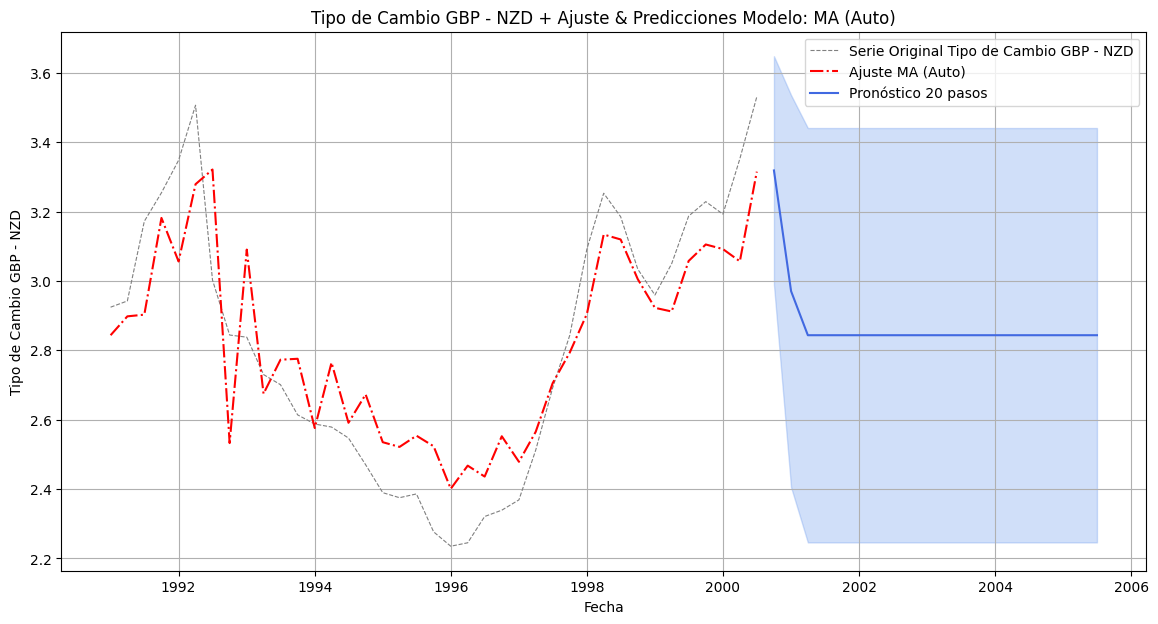

In [16]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['xrate'], label='Serie Original ' + nombreSerie, color = 'gray', linestyle='--', lw = 0.8)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='-.')
# Gráfico Pronóstico puntual
plt.plot(dfFor.index, dfFor['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfFor.index, dfFor['cotaInf'], dfFor['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(True)
plt.show()

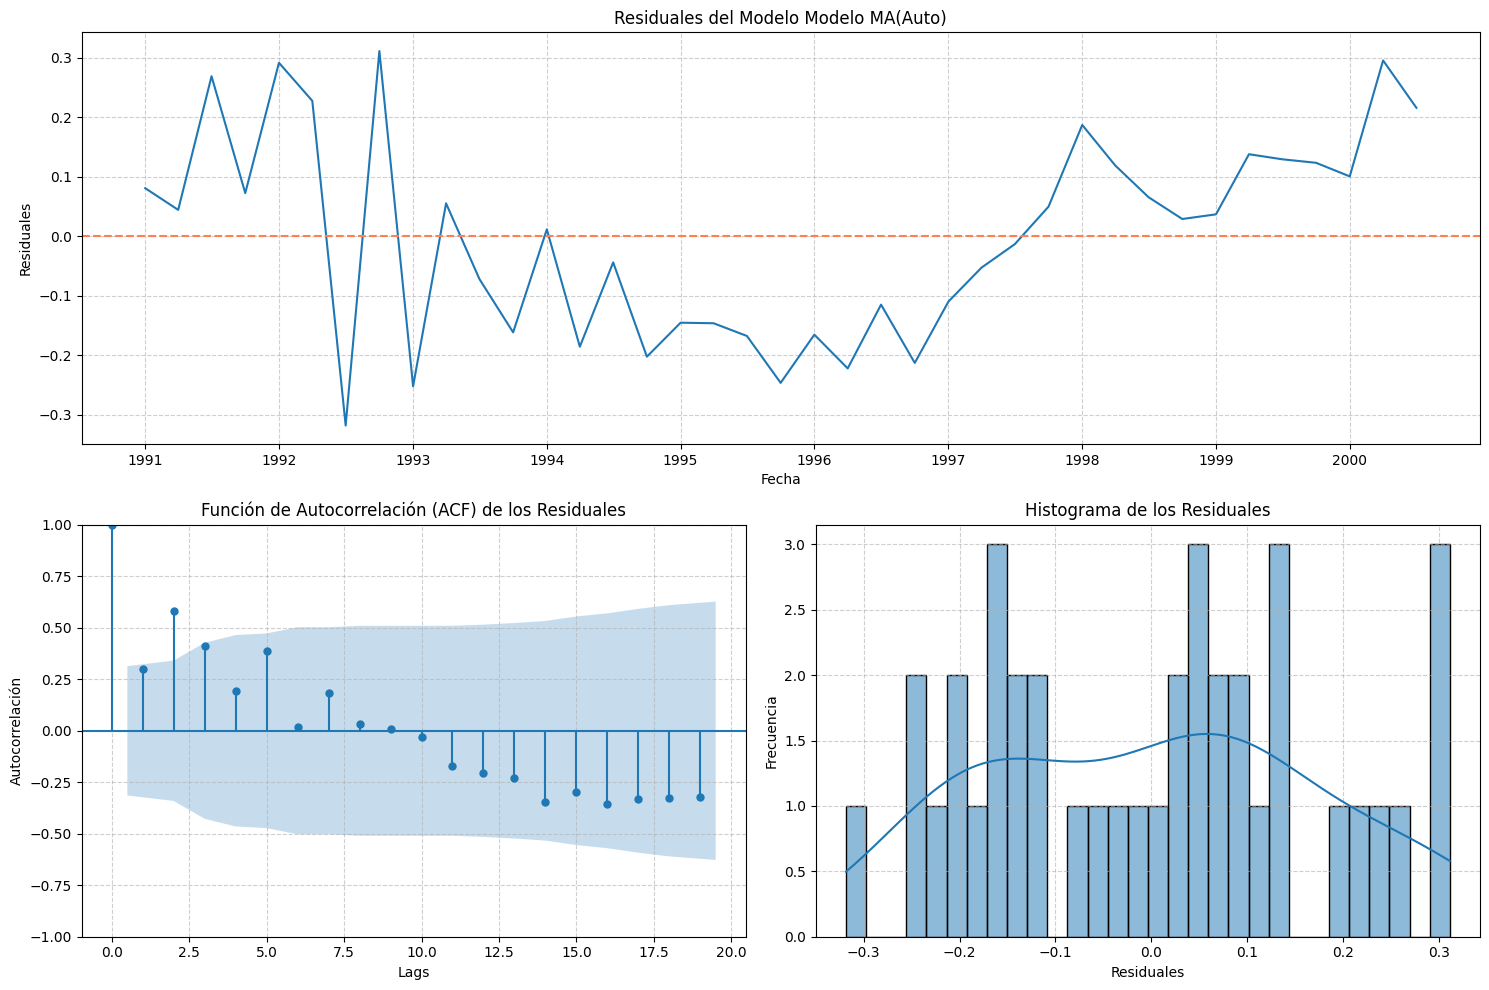

In [17]:
# Gráficos de Residuales
modelo = ma_model
nombre = 'Modelo MA(Auto)'

# Asegurarse de que los residuales sean una Serie con el mismo índice que df
# Ojo porque para modelos ARIMA tenemos que llamar a la función resid() para obtener los residuales
residuales = pd.Series(modelo.resid(), index=df.index)

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=min(len(residuales) // 2, 40), ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Modelo ARMA**

In [18]:
# Definiendo los parámetros para un modelo ARMA(2,2)
# Polinomio AR: 1 - ar1*B - ar2*B^2
# Polinomio MA: 1 + ma1*B + ma2*B^2
# En este ejemplo ar1 = ar2 = ma1 = ma2 = 0.2

# Coeficientes AR para arma_generate_sample son [1, -ar1, -ar2]
ar_coef = [1, -0.2, -0.2]

# Coeficientes MA para arma_generate_sample son [1, 0.2, 0.2]
ma_coef = [1, 0.2, 0.2]

# Generando los datos simulados con un intercepto en -15
arma_sim = -15 + arma_generate_sample(
    ar=ar_coef, ma=ma_coef, nsample=1000
)

arma_sim[:10] # Mostrar los primeros 10 valores

array([-16.29490857, -14.84202839, -15.41501551, -15.40077386,
       -15.68977453, -14.12570869, -16.36925351, -14.48957536,
       -14.34488238, -12.62815528])

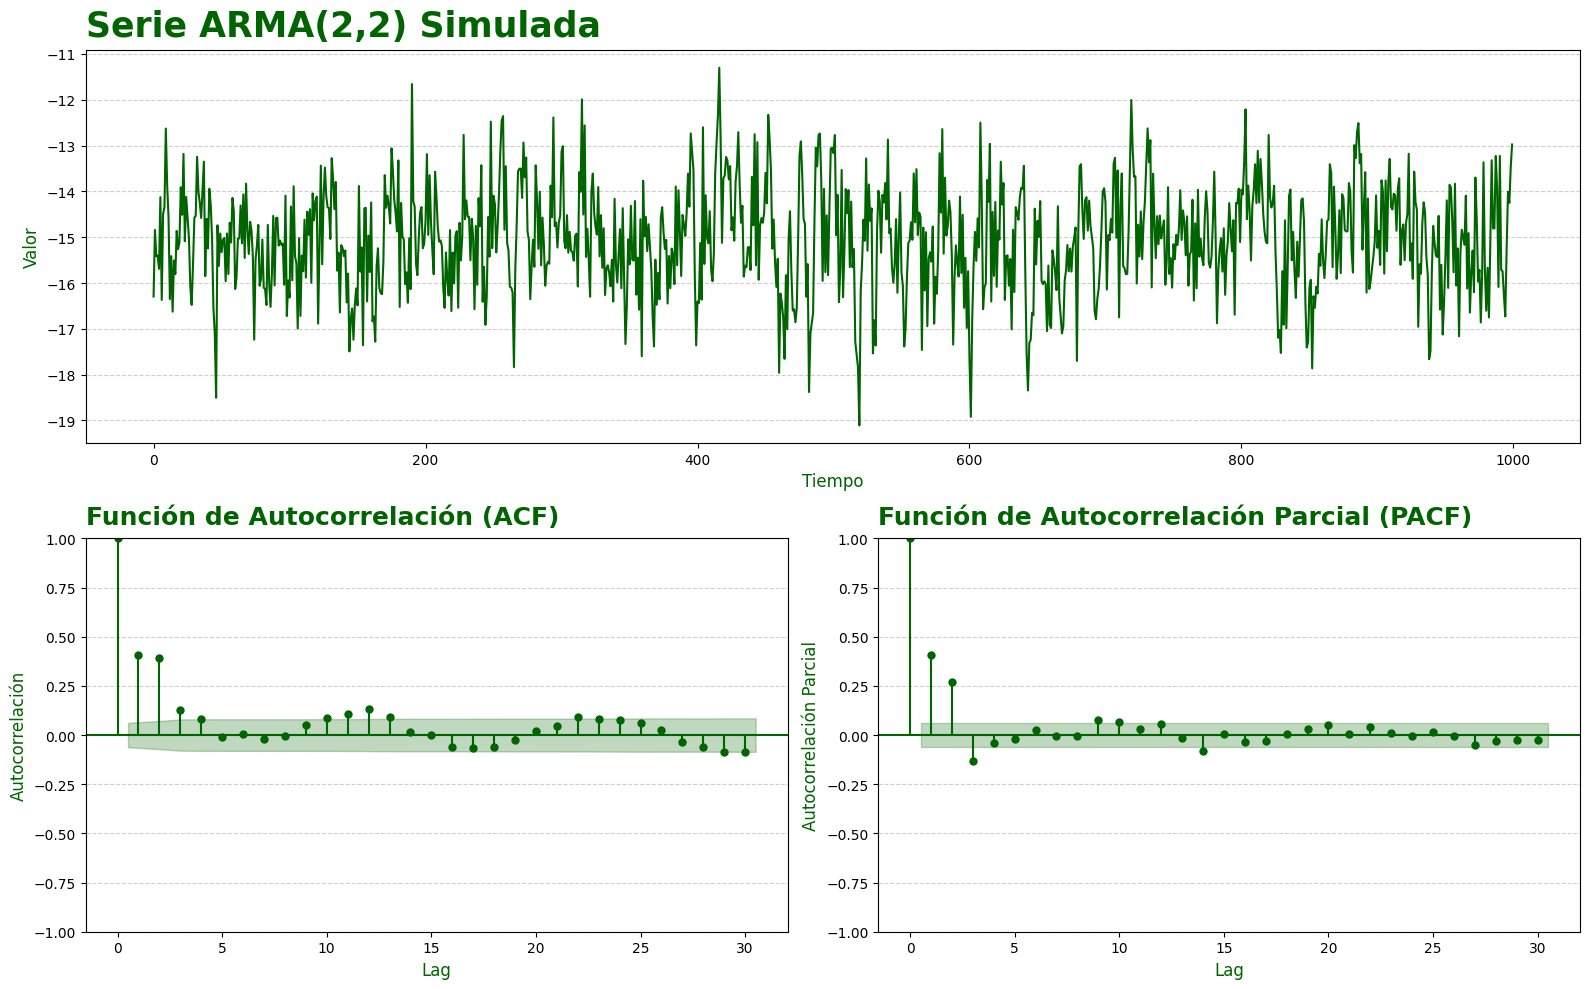

In [19]:
# Gráfico de Simulaciones ARMA(2,2)
serie = arma_sim
nombre = 'ARMA(2,2) Simulada'
graphColor = 'darkgreen'

# Crear la figura y el GridSpec para el layout de 2x2
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Subplot para la serie simulada (ocupa toda la fila superior)
ax0 = fig.add_subplot(gs[0, :]) # gs[0, :] indica la primera fila, todas las columnas
ax0.plot(serie, color = graphColor)
ax0.set_title('Serie ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Tiempo', fontsize=12, color = graphColor,)
ax0.set_ylabel('Valor', fontsize=12, color = graphColor,)
ax0.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la ACF (parte inferior izquierda)
ax1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] indica la segunda fila, primera columna
smt.plot_acf(serie, lags=30, ax=ax1, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y formato
ax1.set_title('Función de Autocorrelación (ACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax1.set_ylabel('Autocorrelación', fontsize=12, color = graphColor)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la PACF (parte inferior derecha)
ax2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] indica la segunda fila, segunda columna
smt.plot_pacf(serie, lags=30, ax=ax2, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y Formato
ax2.set_title('Función de Autocorrelación Parcial (PACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax2.set_ylabel('Autocorrelación Parcial', fontsize=12, color = graphColor)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout() # Ajustar el layout para evitar empalme
plt.show()

## Ajuste de un modelo ARMA a datos reales (NZD-GBP)

In [20]:
# Ajuste de un modelo MA automático con q de 1 a 5
arma_model = auto_arima(df['xrate'],
                       start_p=1, max_p=5,
                       start_q=1, max_q=5,
                       information_criterion = 'bic',
                       stepwise = True, # Utilizando algoritmo stepwise para eficiencia
                       with_intercept = True, # Que incluya un intercepto
                       trace = True, # Visualizar los modelos probados
                       # Parámetros NO utilizados en este momento:
                       seasonal=False,
                       d=0, # Allow auto_arima to determine differencing order
                       D=0
                      )

print(arma_model.summary())

Performing stepwise search to minimize bic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=-35.619, Time=0.54 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=42.132, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : BIC=-32.413, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=195.989, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.22 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : BIC=-32.394, Time=0.22 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : BIC=-11.470, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : BIC=-34.789, Time=0.09 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : BIC=-31.135, Time=0.25 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=-33.184, Time=0.14 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0] intercept
Total fit time: 1.883 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   39
Model:          

In [21]:
# Obtener valores ajustados y predicciones
modelo = arma_model
pasos = 20
nombreSerie = 'Tipo de Cambio GBP - NZD'
nombreModelo = 'ARMA (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Generar predicciones con intervalos de confianza
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfFor = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfFor.head()

Fecha
1991-01-01    2.959734
1991-04-01    2.926390
1991-07-01    2.950772
1991-10-01    3.260275
1992-01-01    3.219389
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2000-10-01,3.532490,3.292037,3.772942
2001-01-01,3.470968,3.052494,3.889441
2001-04-01,3.416054,2.897811,3.934297
2001-07-01,3.367039,2.781349,3.952729
2001-10-01,3.323289,2.688975,3.957602


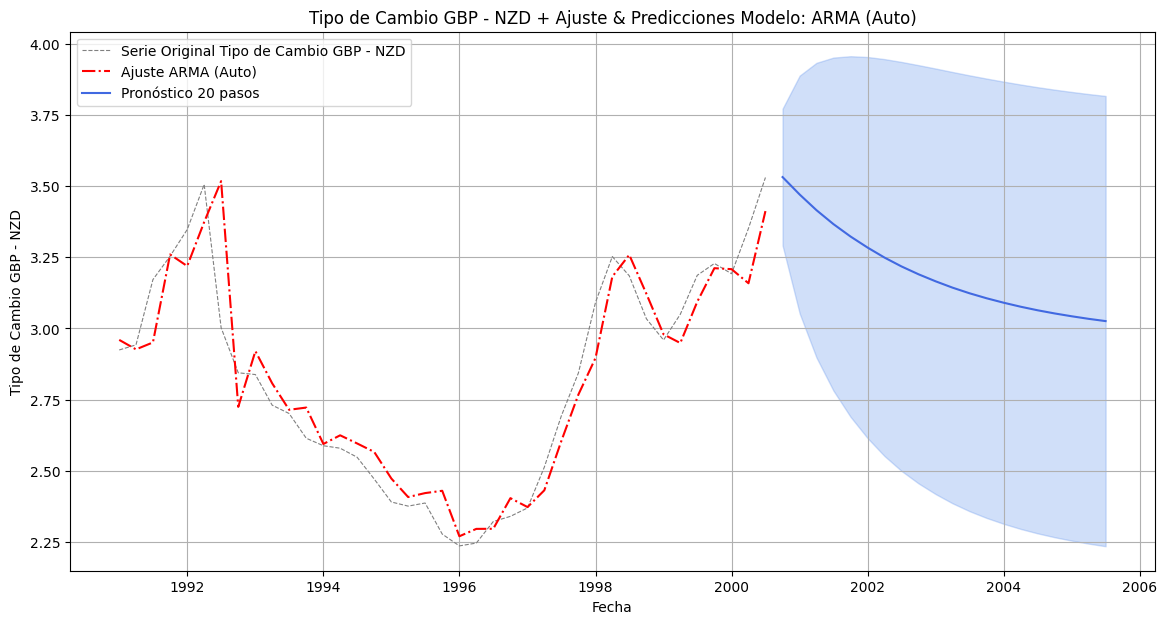

In [22]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['xrate'], label='Serie Original ' + nombreSerie, color = 'gray', linestyle='--', lw = 0.8)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='-.')
# Gráfico Pronóstico puntual
plt.plot(dfFor.index, dfFor['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfFor.index, dfFor['cotaInf'], dfFor['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(True)
plt.show()

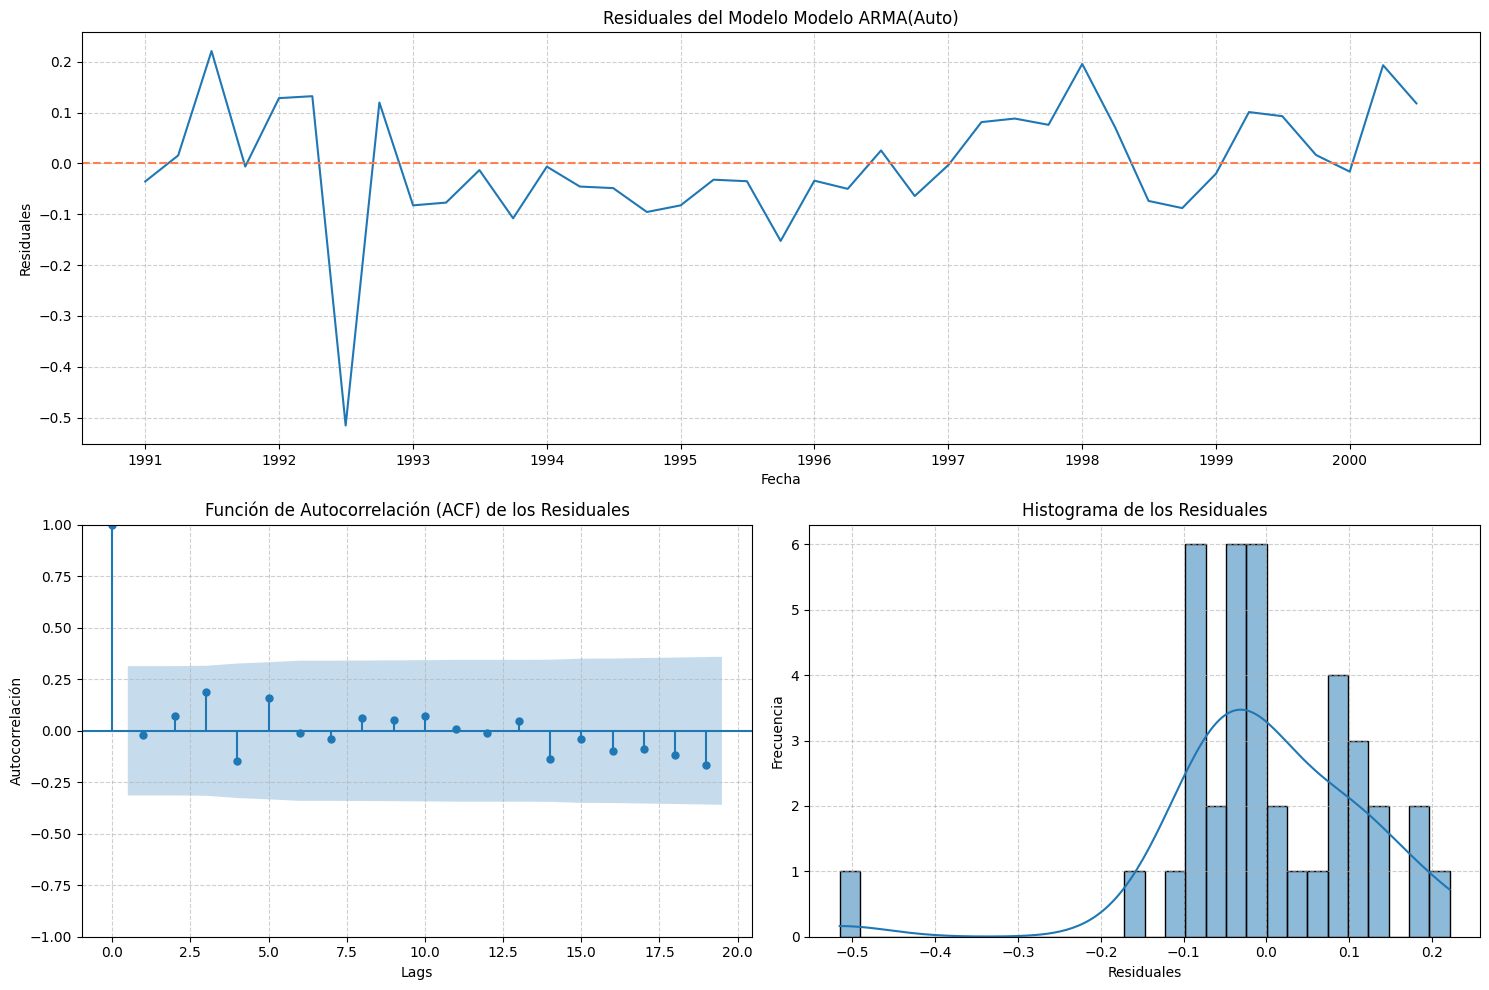

In [23]:
# Gráficos de Residuales
modelo = arma_model
nombre = 'Modelo ARMA(Auto)'

# Asegurarse de que los residuales sean una Serie con el mismo índice que df
# Ojo porque para modelos ARIMA tenemos que llamar a la función resid() para obtener los residuales
residuales = pd.Series(modelo.resid(), index=df.index)

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=min(len(residuales) // 2, 40), ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_62505/2988239568.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


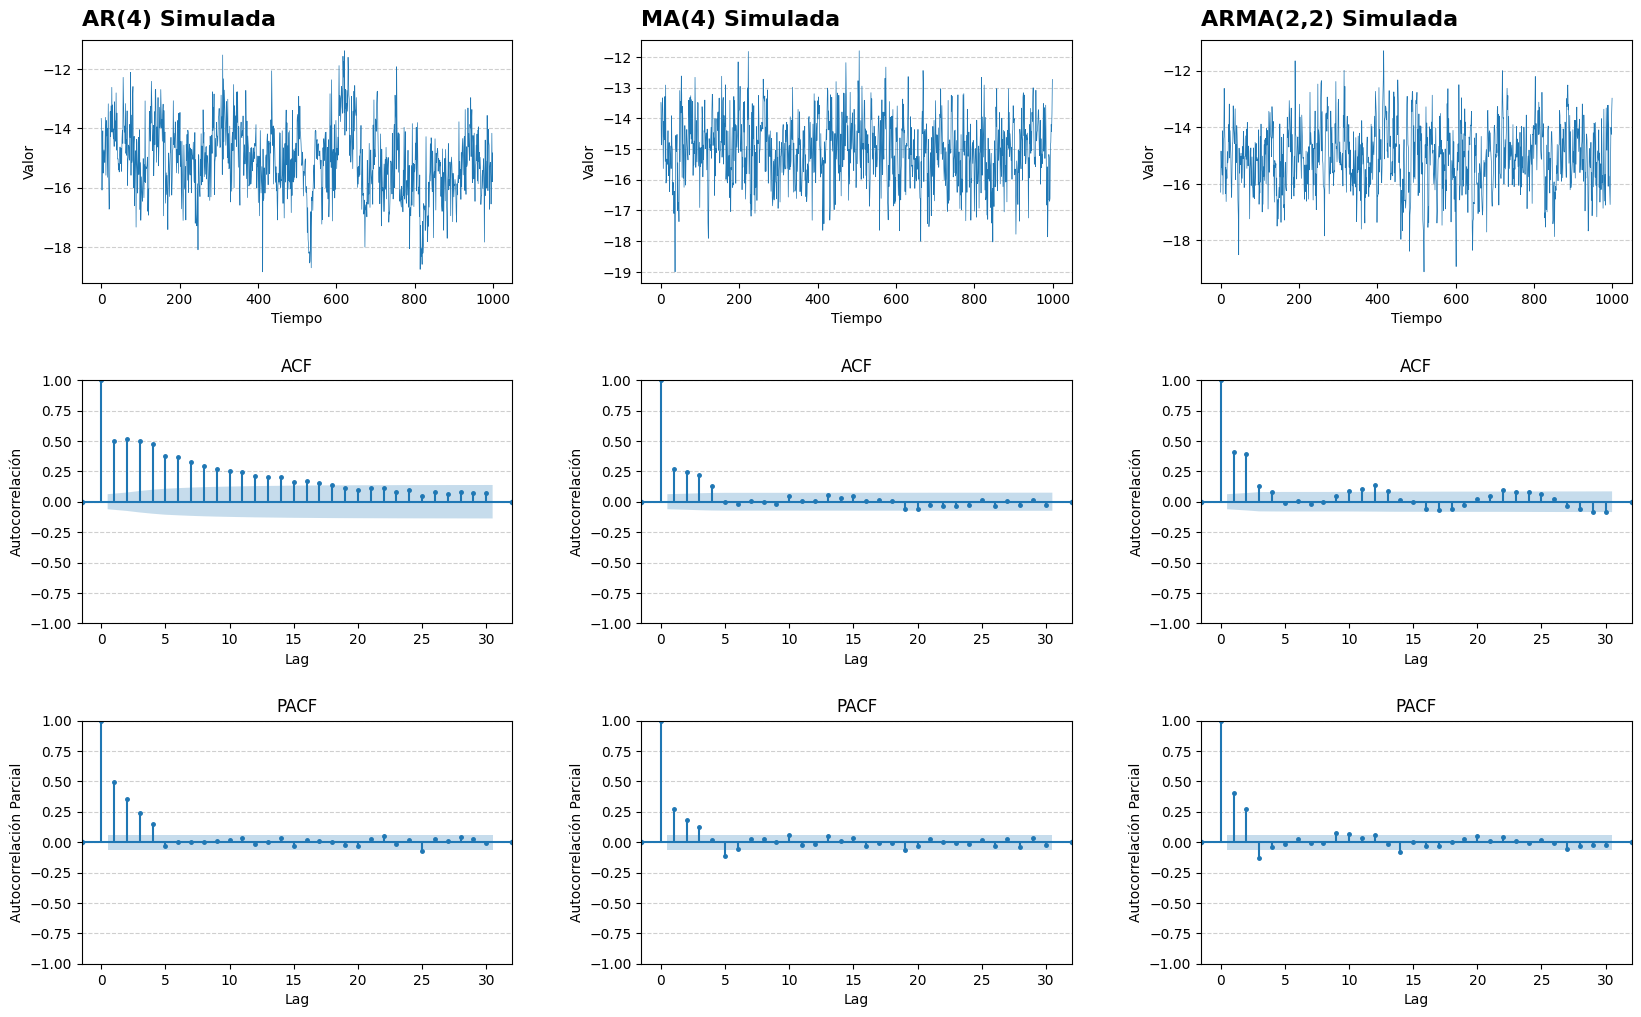

In [24]:
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)


modelos = {
    'AR(4) Simulada': ar_sim,
    'MA(4) Simulada': ma_sim,
    'ARMA(2,2) Simulada': arma_sim
}

# Row 0: Simulated Series
for i, (nombre, datos) in enumerate(modelos.items()):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(datos, lw = 0.5)
    ax.set_title(nombre, loc='left', fontweight='bold', size=16, pad=10)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Valor')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Row 1: ACF Plots
for i, (nombre, datos) in enumerate(modelos.items()):
    ax = fig.add_subplot(gs[1, i])
    smt.plot_acf(datos, lags=30, ax=ax, title='ACF', marker = '.')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelación')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Row 2: PACF Plots
for i, (nombre, datos) in enumerate(modelos.items()):
    ax = fig.add_subplot(gs[2, i])
    smt.plot_pacf(datos, lags=30, ax=ax, title='PACF', marker = '.')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelación Parcial')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ¿Datos con tendencia clara?

In [25]:
# Subir archivo co2.csv
from google.colab import files
files.upload()

Saving co2.csv to co2 (2).csv


{'co2 (2).csv': b'"x"\r\n315.42\r\n316.31\r\n316.5\r\n317.56\r\n318.13\r\n318\r\n316.39\r\n314.65\r\n313.68\r\n313.18\r\n314.66\r\n315.43\r\n316.27\r\n316.81\r\n317.42\r\n318.87\r\n319.87\r\n319.43\r\n318.01\r\n315.74\r\n314\r\n313.68\r\n314.84\r\n316.03\r\n316.73\r\n317.54\r\n318.38\r\n319.31\r\n320.42\r\n319.61\r\n318.42\r\n316.63\r\n314.83\r\n315.16\r\n315.94\r\n316.85\r\n317.78\r\n318.4\r\n319.53\r\n320.42\r\n320.85\r\n320.45\r\n319.45\r\n317.25\r\n316.11\r\n315.27\r\n316.53\r\n317.53\r\n318.58\r\n318.92\r\n319.7\r\n321.22\r\n322.08\r\n321.31\r\n319.58\r\n317.61\r\n316.05\r\n315.83\r\n316.91\r\n318.2\r\n319.41\r\n320.07\r\n320.74\r\n321.4\r\n322.06\r\n321.73\r\n320.27\r\n318.54\r\n316.54\r\n316.71\r\n317.53\r\n318.55\r\n319.27\r\n320.28\r\n320.73\r\n321.97\r\n322\r\n321.71\r\n321.05\r\n318.71\r\n317.66\r\n317.14\r\n318.7\r\n319.25\r\n320.46\r\n321.43\r\n322.23\r\n323.54\r\n323.91\r\n323.59\r\n322.24\r\n320.2\r\n318.48\r\n317.94\r\n319.63\r\n320.87\r\n322.17\r\n322.34\r\n322.88\r\n3

In [26]:
df = pd.read_csv('/content/co2.csv')
df.head()

,x
0,315.42
1,316.31
2,316.50
3,317.56
4,318.13


In [27]:
df['Fecha'] = pd.period_range(start='1959-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.head()

,x
Fecha,
1959-01-01,315.42
1959-02-01,316.31
1959-03-01,316.50
1959-04-01,317.56
1959-05-01,318.13


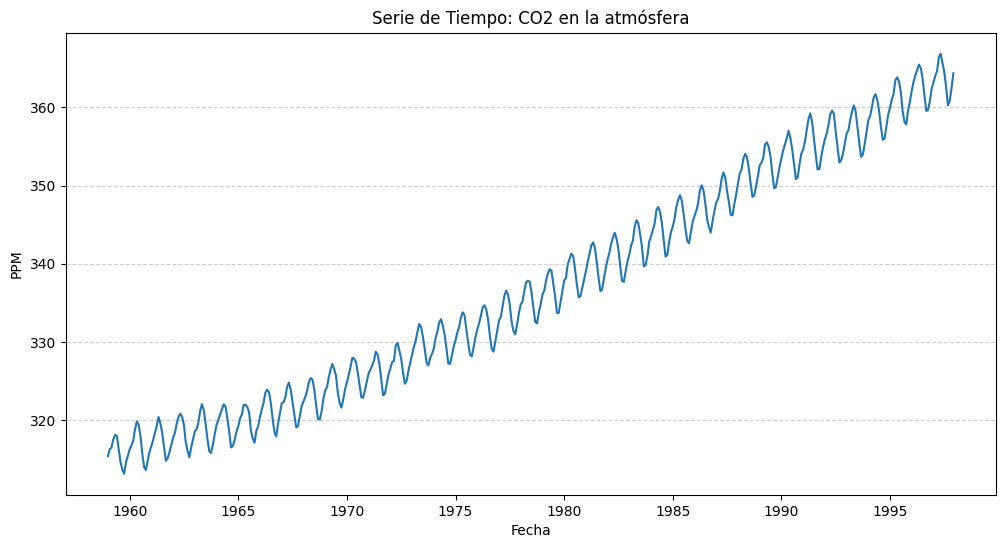

In [28]:
# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['x'])

# Etiquetas
plt.title('Serie de Tiempo: CO2 en la atmósfera')
plt.xlabel('Fecha')
plt.ylabel('PPM')

# Formato
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [29]:
# Ajuste de un modelo MA automático con q de 1 a 5
arma_model_co2 = auto_arima(df['x'],
                       start_p=1, max_p=5,
                       start_q=1, max_q=5,
                       information_criterion = 'aic',
                       stepwise = True, # Prueba con algoritmo stepwise
                       with_intercept = True, # Que incluya un intercepto
                       trace = True, # Visualizar los modelos probados
                       # Parámetros NO utilizados en este momento:
                       seasonal=False,
                       d=0, # Allow auto_arima to determine differencing order
                       D=0
                      )

print(arma_model_co2.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1228.593, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=3863.750, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.45 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=6778.793, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1125.916, Time=2.08 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1192.357, Time=1.60 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=961.343, Time=2.06 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=959.246, Time=1.31 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=1026.327, Time=4.04 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=1031.666, Time=3.16 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=963.359, Time=4.40 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.41

In [30]:
# Obtener valores ajustados y predicciones
modelo = arma_model_co2
pasos = 300
nombreSerie = 'CO2 en la Atmósfera'
nombreModelo = 'ARMA (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Generar predicciones con intervalos de confianza
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfFor = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfFor.head()

Fecha
1959-01-01    339.162587
1959-02-01    315.546163
1959-03-01    317.158043
1959-04-01    316.369304
1959-05-01    318.264712
Freq: MS, dtype: float64


,forecast,cotaInf,cotaSup
1998-01-01,365.798941,364.510833,367.087050
1998-02-01,366.485215,363.911988,369.058442
1998-03-01,366.305090,362.633791,369.976389
1998-04-01,365.437273,361.036867,369.837679
1998-05-01,364.238682,359.486375,368.990989


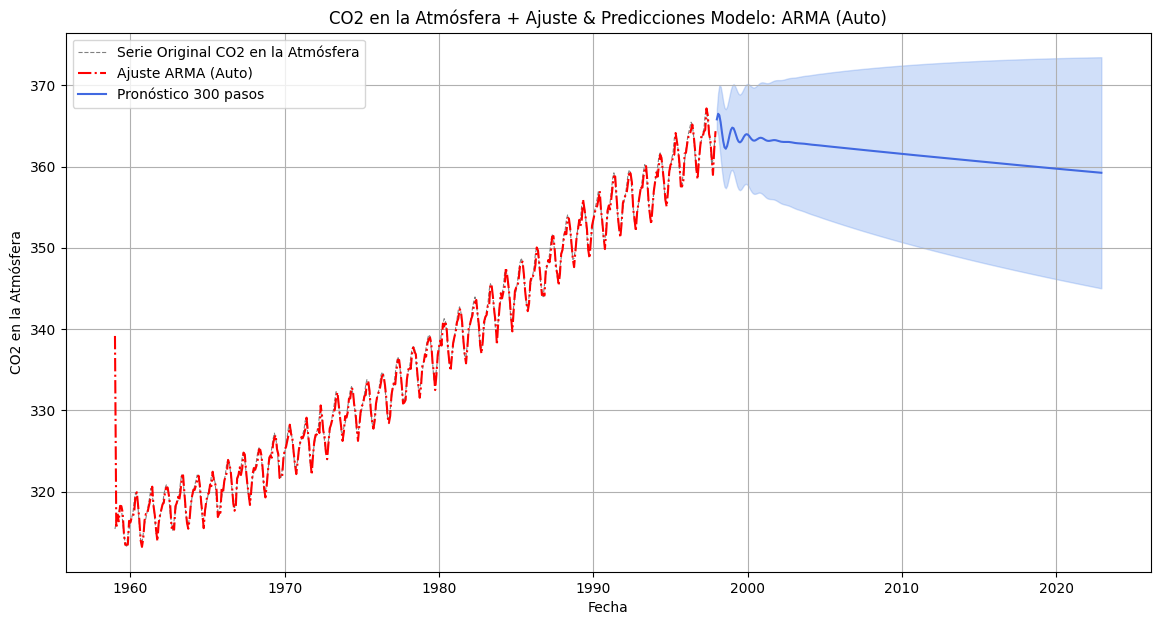

In [31]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color = 'gray', linestyle='--', lw = 0.8)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='-.')
# Gráfico Pronóstico puntual
plt.plot(dfFor.index, dfFor['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfFor.index, dfFor['cotaInf'], dfFor['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(True)
plt.show()